# 1. Spacy & Transformers

## 1.1 Spacy

### 1.1.A Import data

In [2]:
import pandas as pd
df = pd.read_parquet("../../data/examples/week_7/manifesto_english_speaking.parquet")
df.head(2)

party               partyname          keys  \
countryname date                                                      
Australia   1961-12-01  63320  Australian Labor Party  63320_196112   
            1961-12-01  63330  Democratic Labor Party  63330_196112   

                        manifesto_id  \
countryname date                       
Australia   1961-12-01  63320_196112   
            1961-12-01  63330_196112   

                                                                     text  
countryname date                                                           
Australia   1961-12-01  Labour government would subsidise interest rat...  
            1961-12-01  New concepts needed for Nation’s problems.  Me...

### 1.1.1 Convert text to part of speech 

In [3]:
import spacy

nlp = spacy.load("en_core_web_sm")
doc = nlp('Labour government would subsidise interest rates for housing to encourage home-building.')
for token_text in doc:
    print(token_text.text)

Labour
government
would
subsidise
interest
rates
for
housing
to
encourage
home
-
building
.


In [4]:
for token in doc:
    print(
        f"Text: {token.text:<15} "
        f"Lemmas: {token.lemma_:<15} "
        f"POS: {token.pos_:<6} "
        f"Tag: {token.tag_:<5} "
        f"Dep: {token.dep_:<10} "
        f"Shape: {token.shape_:<8} "
        f"Alpha: {str(token.is_alpha):<6} "
        f"Stop: {str(token.is_stop)}"
    )

Text: Labour          Lemmas: labour          POS: ADJ    Tag: JJ    Dep: amod       Shape: Xxxxx    Alpha: True   Stop: False
Text: government      Lemmas: government      POS: NOUN   Tag: NN    Dep: nsubj      Shape: xxxx     Alpha: True   Stop: False
Text: would           Lemmas: would           POS: AUX    Tag: MD    Dep: aux        Shape: xxxx     Alpha: True   Stop: True
Text: subsidise       Lemmas: subsidise       POS: VERB   Tag: VB    Dep: ROOT       Shape: xxxx     Alpha: True   Stop: False
Text: interest        Lemmas: interest        POS: NOUN   Tag: NN    Dep: compound   Shape: xxxx     Alpha: True   Stop: False
Text: rates           Lemmas: rate            POS: NOUN   Tag: NNS   Dep: dobj       Shape: xxxx     Alpha: True   Stop: False
Text: for             Lemmas: for             POS: ADP    Tag: IN    Dep: prep       Shape: xxx      Alpha: True   Stop: True
Text: housing         Lemmas: housing         POS: NOUN   Tag: NN    Dep: pobj       Shape: xxxx     Alpha: True 

### 1.1.2 Entity extraction

In [5]:
text = """
    Preamble With this platform, we the Republican Party reaffirm the principles that unite us in a common purpose. 
    We believe in American exceptionalism.
    We believe the United States of America is unlike any other nation on earth."""
doc = nlp(text)
for ent in doc.ents:
    print(ent.text, ent.label_)

the Republican Party ORG
American NORP
the United States of America GPE


### 1.1.3 Pipeline

100%|██████████| 10/10 [00:18<00:00,  1.88s/it]



Top 10 Most Common Adjectives:
[('american', 838), ('federal', 747), ('new', 607), ('public', 532), ('economic', 507), ('national', 407), ('high', 397), ('strong', 333), ('good', 314), ('private', 313)]

Top 10 Most Common Verbs:
[('support', 1115), ('include', 681), ('work', 663), ('ensure', 631), ('protect', 625), ('believe', 558), ('provide', 493), ('create', 450), ('continue', 443), ('help', 440)]


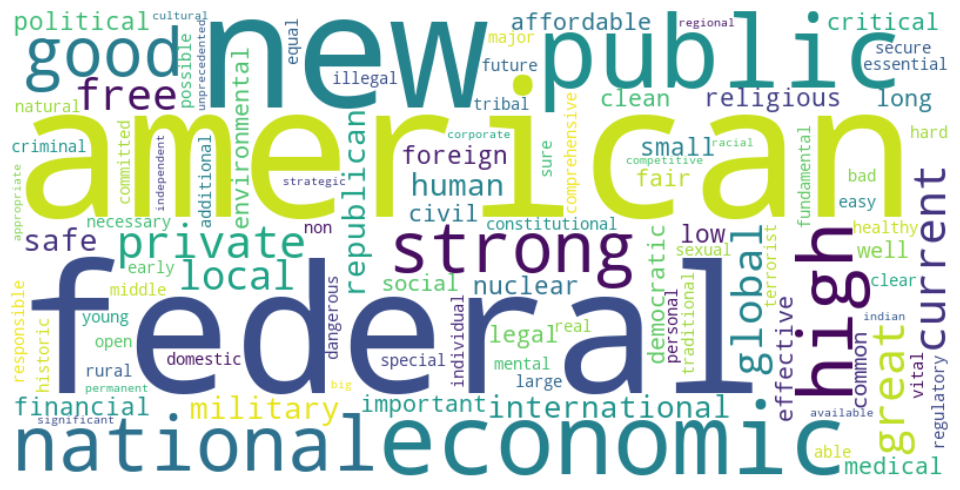

partyname  \
countryname   date                           
United States 2004-11-01  Democratic Party   
              2004-11-01  Republican Party   

                                                                       text  \
countryname   date                                                            
United States 2004-11-01  PREAMBLE As we come together to declare our vi...   
              2004-11-01  INTRODUCTION AND PREAMBLE One hundred and fift...   

                                                      environment_sentences  
countryname   date                                                           
United States 2004-11-01  [We will conduct a global cleanout initiative ...  
              2004-11-01  [Our plans focus on ensuring that America rema...

In [6]:
from collections import Counter
import matplotlib.pyplot as plt
import pandas as pd
import spacy
from tqdm import tqdm
from wordcloud import WordCloud

nlp = spacy.load("en_core_web_sm")

df_nlp = df.tail(10).copy()
texts = df_nlp["text"].astype(str).tolist()

docs = list(tqdm(nlp.pipe(texts, disable=["ner"]), total=len(df_nlp)))

environment_terms = {
    "acid", "climate", "conservation", "emission", "emissions",
    "energy", "environment", "environmental", "facility", "greenhouse",
    "mercury", "pollution", "renewable", "science", "smog",
    "sustainable", "sustainability",
}

def get_matching_sentences(doc, terms):
    matches = []
    for sent in doc.sents:
        lemmas = {token.lemma_.lower() for token in sent if token.is_alpha}
        if lemmas & terms:
            matches.append(sent.text.strip())
    return matches

df_nlp["environment_sentences"] = [
    get_matching_sentences(doc, environment_terms) for doc in docs
]

adjective_pool = []
verb_pool = []

for doc in docs:
    for token in doc:
        if token.is_alpha and not token.is_stop:
            if token.pos_ == "ADJ":
                adjective_pool.append(token.lemma_.lower())
            elif token.pos_ == "VERB":
                verb_pool.append(token.lemma_.lower())

adj_counts = Counter(adjective_pool)
verb_counts = Counter(verb_pool)

print("\nTop 10 Most Common Adjectives:")
print(adj_counts.most_common(10))

print("\nTop 10 Most Common Verbs:")
print(verb_counts.most_common(10))

if adj_counts:
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color="white",
        max_words=100,
    ).generate_from_frequencies(adj_counts)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.tight_layout()
    plt.show(block=False)
    plt.close()
else:
    print("No adjectives were found in the processed text.")

df_nlp[["partyname", "text", "environment_sentences"]].head(2)

## 1.2 Transformers

### 1.2.1 Load a ManifestoBERTa Model

In [5]:
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer

MODEL_NAME = "manifesto-project/manifestoberta-xlm-roberta-56policy-topics-sentence-2024-1-1"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
model.eval()

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: manifesto-project/manifestoberta-xlm-roberta-56policy-topics-sentence-2024-1-1
Key                     | Status     |  | 
------------------------+------------+--+-
final_classifier.bias   | UNEXPECTED |  | 
final_classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


XLMRobertaForSequenceClassification(
  (classifier): XLMRobertaClassificationHead(
    (dense): Linear(in_features=1024, out_features=1024, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (out_proj): Linear(in_features=1024, out_features=56, bias=True)
  )
  (roberta): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(250002, 1024, padding_idx=1)
      (token_type_embeddings): Embedding(1, 1024)
      (LayerNorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 1024, padding_idx=1)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-23): 24 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSelfAttention(
              (query): Linear(in_features=1024, out_features=1024, bias=True)
              (key): Linear(in_features=1024, out_features=1024, bias=True)
  

In [6]:
sentence = "We will restore funding to the Global Environment Facility and the Intergovernmental Panel on Climate Change, to support critical climate science research around the world."

inputs = tokenizer(
    sentence,
    return_tensors="pt",
    max_length=200,
    padding="max_length",
    truncation=True,
)

with torch.no_grad():
    logits = model(**inputs).logits

probabilities = torch.softmax(logits, dim=1).tolist()[0]
probabilities = {
    model.config.id2label[index]: round(probability * 100, 2)
    for index, probability in enumerate(probabilities)
}
probabilities = dict(sorted(probabilities.items(), key=lambda item: item[1], reverse=True))

In [7]:

predicted_class = model.config.id2label[logits.argmax().item()]
top_probabilities = {
    category: probability
    for category, probability in probabilities.items()
    if probability > 2
}

top_probabilities

{'110 - European Community/Union: Negative': 3.06,
 '606 - Civic Mindedness: Positive': 2.59,
 '106 - Peace': 2.58,
 '413 - Nationalisation': 2.56,
 '303 - Governmental and Administrative Efficiency': 2.52,
 '603 - Traditional Morality: Positive': 2.38,
 '102 - Foreign Special Relationships: Negative': 2.36,
 '604 - Traditional Morality: Negative': 2.35,
 '703 - Agriculture and Farmers: Positive': 2.3,
 '302 - Centralisation': 2.29,
 '401 - Free Market Economy': 2.23,
 '104 - Military: Positive': 2.15,
 '204 - Constitutionalism: Negative': 2.14,
 '403 - Market Regulation': 2.14,
 '202 - Democracy': 2.12,
 '414 - Economic Orthodoxy': 2.07,
 '304 - Political Corruption': 2.02}

### 1.2.2 Apply to the Earlier Example

#### Function

In [12]:
def clean_manifesto_label(label):
    return label.split(" - ", 1)[1] if " - " in label else label


def get_top_probabilities(sentence, label_probability_threshold=10):
    inputs = tokenizer(
        sentence,
        return_tensors="pt",
        max_length=200,
        padding="max_length",
        truncation=True,
    )

    with torch.no_grad():
        logits = model(**inputs).logits

    probabilities = torch.softmax(logits, dim=1).tolist()[0]
    probabilities = {
        model.config.id2label[index]: round(probability * 100, 2)
        for index, probability in enumerate(probabilities)
    }
    probabilities = dict(sorted(probabilities.items(), key=lambda item: item[1], reverse=True))

    labels = [
        clean_manifesto_label(label)
        for label, probability in probabilities.items()
        if probability > label_probability_threshold
    ]
    if not labels:
        labels = [clean_manifesto_label(next(iter(probabilities)))]
    return labels


sentence = "We will restore funding to the Global Environment Facility and the Intergovernmental Panel on Climate Change, to support critical climate science research around the world."
top_probs = get_top_probabilities(sentence, label_probability_threshold=10)
print(top_probs)

['European Community/Union: Negative']


#### For loop

In [ ]:
df_nlp['transformer_labels'] = transformer_sentiment
df_nlp.head(2)

NameError: name 'transformer_sentiment' is not defined

#### Count number of labels for each year, country, partyname

In [ ]:
index_cols = ["countryname", "date", "partyname"]

df_label_counts = (
    df_nlp.set_index(index_cols)["transformer_labels"]
    .explode()
    .explode()
    .dropna()
    .groupby(index_cols)
    .value_counts()
    .rename("count")
    .reset_index()
)

df_label_counts.head(3)

NameError: name 'df_nlp' is not defined

#### Graph

In [10]:
import seaborn as sns

labels = sorted(df_label_counts["transformer_labels"].dropna().unique())
palette = dict(zip(labels, sns.color_palette("tab10", n_colors=max(len(labels), 1))))

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, party in zip(axes, ["Democratic Party", "Republican Party"]):
    plot_data = df_label_counts.query("partyname == @party").sort_values("transformer_labels")
    if plot_data.empty:
        ax.set_axis_off()
        ax.set_title(f"{party} (no labels)")
        continue

    sns.barplot(
        ax=ax,
        data=plot_data,
        x="date",
        y="count",
        hue="transformer_labels",
        palette=palette,
    )
    ax.set_title(party)
    ax.tick_params(axis="x", rotation=45)
    ax.set_xlabel("Date")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show(block=False)
plt.close()

NameError: name 'df_label_counts' is not defined

In [11]:
if df_label_counts.empty:
    print("No transformer labels to plot.")
else:
    sns.relplot(
        data=df_label_counts,
        x="date",
        y="count",
        hue="transformer_labels",
        col="partyname",
        kind="line",
    )

NameError: name 'df_label_counts' is not defined